In [1]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

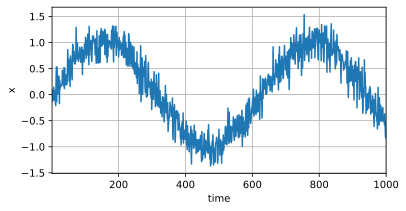

In [2]:
T = 1000
time = torch.arange(1, T+1, dtype=torch.float32)
x = torch.sin(0.01*time) + torch.normal(0, 0.2, (T, ))
d2l.plot(time, [x], 'time', 'x', xlim=[1,1000],figsize=(6,3))

In [4]:
tau = 4
features = torch.zeros((T-tau, tau))
for i in range(tau):
        features[:, i] = x[i:T-tau+i]
labels = x[tau:].reshape((-1, 1))

batch_size=16
n_train = 600
train_iter = d2l.load_array((features[:n_train], labels[:n_train]), batch_size, is_train=True)

In [5]:
def init_weight(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)

net = nn.Sequential(
    nn.Linear(4, 10), nn.ReLU(), 
    nn.Linear(10, 1)
)
net.apply(init_weight)


Sequential(
  (0): Linear(in_features=4, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [6]:
loss = nn.MSELoss(reduction='none')

In [9]:
def train(net, train_iter, loss, epochs, lr):
    trainer = torch.optim.Adam(net.parameters(), lr)
    for epoch in range(epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.sum().backward()
            trainer.step()
        print(f'epoch {epoch+1}, ',f'loss: {d2l.evaluate_loss(net, train_iter, loss):f}')

train(net, train_iter, loss, 5, 0.01)

epoch 1,  loss: 0.054859
epoch 2,  loss: 0.049839
epoch 3,  loss: 0.047837
epoch 4,  loss: 0.047520
epoch 5,  loss: 0.049012


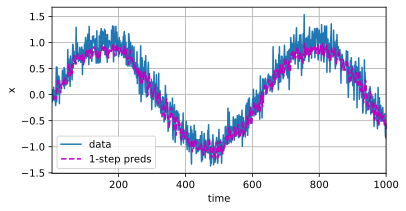

In [10]:
onestep_preds = net(features)
d2l.plot([time, time[tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy()],
        'time','x',legend=['data','1-step preds'],
        xlim=[1, 1000],figsize=(6,3))

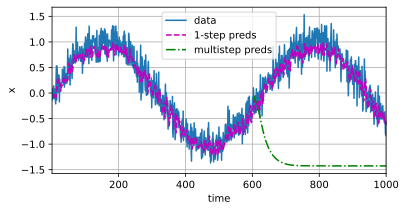

In [15]:
multistep_preds = torch.zeros(T)
multistep_preds[:n_train+tau] = x[:n_train+tau]

for i in range(n_train+tau, T):
    multistep_preds[i] = net(multistep_preds[i-tau:i].reshape((1, -1)))

d2l.plot([time, time[tau:], time[n_train+tau:]],
         [x.detach().numpy(), onestep_preds.detach().numpy(), multistep_preds[n_train + tau:].detach().numpy()],
        'time','x',legend=['data','1-step preds', 'multistep preds'],
        xlim=[1, 1000],figsize=(6,3))